In [48]:
from google.colab import drive
drive.mount('/content/drive')

KeyboardInterrupt: 

In [49]:
%cd /content/drive/MyDrive/tinyllama_qlora

!pwd


!ls


/content/drive/MyDrive/tinyllama_qlora
/content/drive/MyDrive/tinyllama_qlora
fine_tunning_ploted_graph  notebooks  outputs  README.md  requirements.txt  src


In [50]:
!pip install -r requirements.txt

In [29]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: Tesla T4


# *LOAD DATA SETS*

In [30]:
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
DATASET_NAME = "databricks/databricks-dolly-15k"

In [44]:
from src.tokenizer.tokenizer_loader import load_tokenizer

tokenizer = load_tokenizer(model_name=MODEL_NAME)

In [32]:
from src.data.pipeline import pipeline

data_set = pipeline(dataset=DATASET_NAME, tokenizer=tokenizer)

# *LOAD MODEL*

In [33]:
from src.model.pipeline import pipeline

base_model, lora_model = pipeline(model_name=MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:212: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


# *TRAIN MODEL*

In [34]:
from src.training.pipeline import pipeline

trainer = pipeline(model=lora_model, dataset=data_set)

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss


In [ ]:
from src.training.save_adapter import save

save(tokenizer=tokenizer, trainer=trainer)

TypeError: save() got an unexpected keyword argument 'tokenizer'

# *INFERENCE*

In [55]:
from src.inference.pipeline import pipeline

pipeline(base_model=base_model, prompt="Explain Machine Learning in simple words.")

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:190: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:447: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Fine tuned model res:
 <|user|>
Explain Machine Learning in simple words. 
<|assistant|>
Machine Learning is a set of algorithms that allows machines to learn from data without being explicitly programmed. It is an important area of computer science that enables machines to learn from unstructured data without explicit programming. 

Machine learning algorithms are designed to be able to adapt quickly to new data. It is often used in fields such as recommendation systems, chatbots, and natural language processing.
Base model res:
 <|user|>
Explain Machine Learning in simple words. 
<|assistant|>
Machine Learning is a process of learning and improving a system or a model without retraining the system. It involves collecting large amounts of data, creating algorithms that use that data to learn patterns and predictions, and then using those learned patterns and predictions to make predictions. 

One of the key advantages of Machine Learning is that it can be applied to a wide variety of 

In [51]:
import json

src = "outputs/final_adapter/trainer_state.json"

with open(src, "r") as f:
    trainer_state=json.load(f)

logs = trainer_state["log_history"]

In [52]:
steps = []
losses = []

for log in logs:
    if "loss" in log:
        steps.append(log["step"])
        losses.append(log["loss"])

In [53]:
!pip install matplotlib

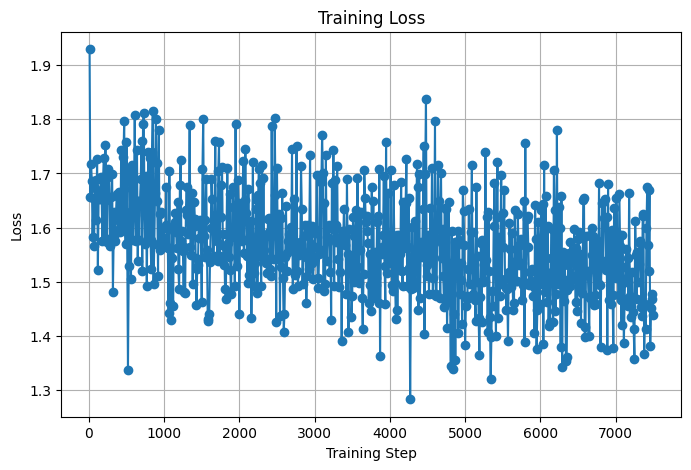

In [54]:


import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(steps, losses, marker="o")
plt.title("Training Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.grid(True)
plt.show()